# 🖼️ Computer Vision Interactive - Reconnaissance d'Objets

## 🎯 Objectifs
- Entraîner un modèle sur un dataset réel (CIFAR-10)
- Interface interactive pour tester vos propres images
- Métriques complètes d'évaluation
- Visualisation des résultats et erreurs

---
*Session 05 - SupNum Nouakchott - Formation IA & Machine Learning*

In [2]:
%pip install --upgrade pip

# Essai 1 (recommandé) :
%pip install "opencv-python==4.10.0.84" --prefer-binary

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 18.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ------- -------------------------------- 7.6/38.8 MB 39.3 MB/s eta 0:00:01
   ----------------- ---------------------- 16.5/38.8 MB 40.0 MB/s eta 0:00:01
   -------------------------- ------------- 25.4/38.8 MB 40.3 MB/s eta 0:00:01
   ----------------------------------- ---- 34.3/38.8 MB 41.2 MB/s eta 0:00:01
   ---------------------------------------- 38.8/38.8 MB 36.8 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import base64
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration pour de beaux graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🚀 Bibliothèques chargées avec succès!")

🚀 Bibliothèques chargées avec succès!


## 📊 1. Chargement et Exploration du Dataset CIFAR-10

### 🤔 Qu'est-ce que CIFAR-10 ?
CIFAR-10 est un dataset célèbre contenant 60,000 images couleur de 32x32 pixels réparties en 10 classes :
- ✈️ Avion (airplane)
- 🚗 Automobile  
- 🐦 Oiseau (bird)
- 🐱 Chat (cat)
- 🦌 Cerf (deer)
- 🐕 Chien (dog)
- 🐸 Grenouille (frog)
- 🐎 Cheval (horse)
- 🚢 Bateau (ship)
- 🚛 Camion (truck)

In [4]:
# Chargement du dataset CIFAR-10
print("📥 Chargement du dataset CIFAR-10...")
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Noms des classes
class_names = ['Avion', 'Automobile', 'Oiseau', 'Chat', 'Cerf', 
               'Chien', 'Grenouille', 'Cheval', 'Bateau', 'Camion']

print(f"✅ Dataset chargé!")
print(f"📊 Images d'entraînement: {x_train.shape}")
print(f"📊 Images de test: {x_test.shape}")
print(f"🎯 Labels d'entraînement: {y_train.shape}")
print(f"🎯 Labels de test: {y_test.shape}")

📥 Chargement du dataset CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
✅ Dataset chargé!
📊 Images d'entraînement: (50000, 32, 32, 3)
📊 Images de test: (10000, 32, 32, 3)
🎯 Labels d'entraînement: (50000, 1)
🎯 Labels de test: (10000, 1)


## 🔍 2. Exploration Visuelle des Données

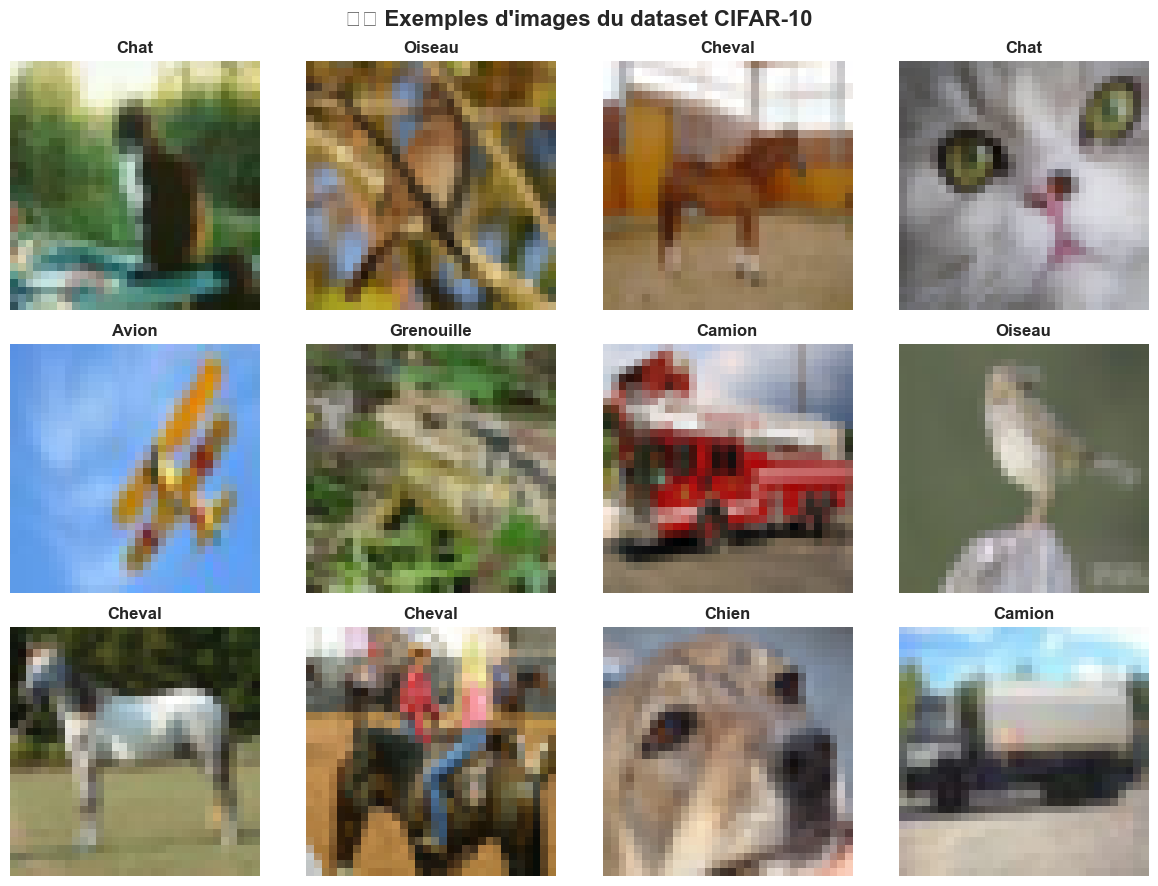

In [5]:
# Fonction pour afficher des exemples d'images
def plot_sample_images(x_data, y_data, class_names, n_samples=12):
    """Affiche des exemples d'images du dataset"""
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    fig.suptitle('🖼️ Exemples d\'images du dataset CIFAR-10', fontsize=16, fontweight='bold')
    
    for i in range(n_samples):
        row = i // 4
        col = i % 4
        
        # Sélection aléatoire d'une image
        idx = np.random.randint(0, len(x_data))
        image = x_data[idx]
        label = class_names[y_data[idx][0]]
        
        axes[row, col].imshow(image)
        axes[row, col].set_title(f'{label}', fontsize=12, fontweight='bold')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Affichage d'exemples
plot_sample_images(x_train, y_train, class_names)

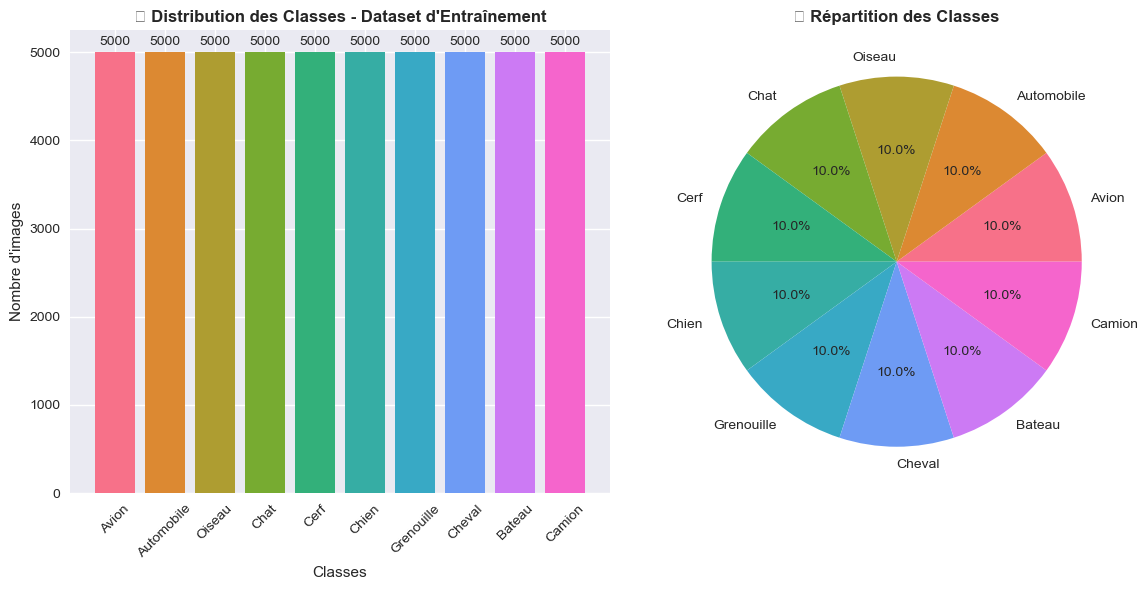

📈 Analyse de la distribution:
✅ Dataset équilibré : chaque classe a exactement 5000 images d'entraînement


In [6]:
# Distribution des classes
plt.figure(figsize=(12, 6))
unique, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip([class_names[i] for i in unique], counts))

plt.subplot(1, 2, 1)
bars = plt.bar(class_counts.keys(), class_counts.values(), color=sns.color_palette("husl", 10))
plt.title('📊 Distribution des Classes - Dataset d\'Entraînement', fontweight='bold')
plt.xlabel('Classes')
plt.ylabel('Nombre d\'images')
plt.xticks(rotation=45)

# Ajout des valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%', 
        colors=sns.color_palette("husl", 10))
plt.title('🥧 Répartition des Classes', fontweight='bold')

plt.tight_layout()
plt.show()

print("📈 Analyse de la distribution:")
print("✅ Dataset équilibré : chaque classe a exactement 5000 images d'entraînement")

## 🔧 3. Préparation des Données

### 📝 Étapes de préparation :
1. **Normalisation** : Convertir les pixels de [0,255] vers [0,1]
2. **Reshape des labels** : Format compatible avec Keras
3. **Validation split** : Séparer une partie pour la validation

In [7]:
# Préparation des données
print("🔧 Préparation des données...")

# Normalisation des images (0-255 -> 0-1)
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Reshape des labels
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

# Split train/validation
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_norm, y_train_flat, test_size=0.2, random_state=42, stratify=y_train_flat
)

print(f"✅ Données préparées!")
print(f"📊 Entraînement: {x_train_final.shape[0]} images")
print(f"📊 Validation: {x_val.shape[0]} images") 
print(f"📊 Test: {x_test_norm.shape[0]} images")

# Vérification de la normalisation
print(f"🔍 Valeurs pixels - Min: {x_train_norm.min():.3f}, Max: {x_train_norm.max():.3f}")

🔧 Préparation des données...
✅ Données préparées!
📊 Entraînement: 40000 images
📊 Validation: 10000 images
📊 Test: 10000 images
🔍 Valeurs pixels - Min: 0.000, Max: 1.000


## 🏗️ 4. Construction du Modèle CNN

### 🧠 Architecture du modèle :
- **Couches Convolutionnelles** : Extraction de caractéristiques
- **Pooling** : Réduction de dimensionnalité
- **Dropout** : Régularisation contre le surapprentissage
- **Dense** : Classification finale

In [8]:
def create_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    """Création d'un modèle CNN pour CIFAR-10"""
    
    model = keras.Sequential([
        # Premier bloc convolutionnel
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, name='conv1'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        layers.Dropout(0.25),
        
        # Deuxième bloc convolutionnel
        layers.Conv2D(64, (3, 3), activation='relu', name='conv3'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', name='conv4'),
        layers.MaxPooling2D((2, 2), name='pool2'),
        layers.Dropout(0.25),
        
        # Troisième bloc convolutionnel
        layers.Conv2D(128, (3, 3), activation='relu', name='conv5'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        
        # Classification
        layers.Flatten(),
        layers.Dense(512, activation='relu', name='dense1'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model

# Création du modèle
model = create_cnn_model()

# Compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Affichage de l'architecture
print("🏗️ Architecture du modèle CNN:")
model.summary()

🏗️ Architecture du modèle CNN:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737,834 (2.81 MB)

 Trainable params: 736,362 (2.81 MB)

 Non-trainable params: 1,472 (5.75 KB)

## 🚀 5. Entraînement du Modèle

### ⚙️ Configuration d'entraînement :
- **Epochs** : 20 (ajustable selon les ressources)
- **Batch size** : 32
- **Callbacks** : Early stopping, réduction du learning rate

In [9]:
# Callbacks pour un meilleur entraînement
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.0001,
        verbose=1
    )
]

print("🚀 Début de l'entraînement...")
print("⏱️ Cela peut prendre quelques minutes...")

# Entraînement
history = model.fit(
    x_train_final, y_train_final,
    batch_size=32,
    epochs=20,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("✅ Entraînement terminé!")

🚀 Début de l'entraînement...
⏱️ Cela peut prendre quelques minutes...
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 98s 67ms/step - accuracy: 0.3921 - loss: 1.8291 - val_accuracy: 0.4988 - val_loss: 1.4350 - learning_rate: 0.0010
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 92s 73ms/step - accuracy: 0.5558 - loss: 1.2525 - val_accuracy: 0.5928 - val_loss: 1.1787 - learning_rate: 0.0010
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 72s 58ms/step - accuracy: 0.6251 - loss: 1.0624 - val_accuracy: 0.6113 - val_loss: 1.1966 - learning_rate: 0.0010
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 69ms/step - accuracy: 0.6630 - loss: 0.9542 - val_accuracy: 0.6743 - val_loss: 0.9389 - learning_rate: 0.0010
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 69ms/step - accuracy: 0.6875 - loss: 0.8899 - val_accuracy: 0.6679 - val_loss: 0.9475 - learning_rate: 0.0010
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.7135 - loss: 0.8233 - val_accuracy: 0.6882 - val_loss: 0.8801 - learning_rate: 0

## 📈 6. Visualisation de l'Entraînement

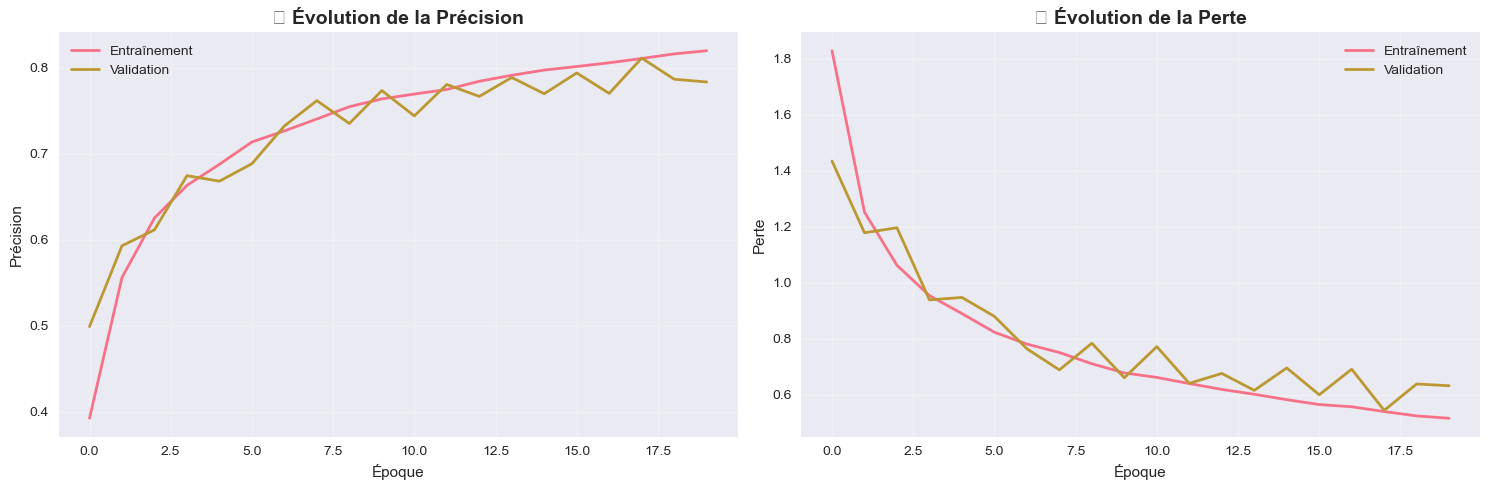

🎯 Précision finale - Entraînement: 0.820
🎯 Précision finale - Validation: 0.783
✅ Modèle bien équilibré


In [10]:
def plot_training_history(history):
    """Visualise l'historique d'entraînement"""
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Entraînement', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0].set_title('📊 Évolution de la Précision', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Époque')
    axes[0].set_ylabel('Précision')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Entraînement', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[1].set_title('📉 Évolution de la Perte', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Époque')
    axes[1].set_ylabel('Perte')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Métriques finales
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"🎯 Précision finale - Entraînement: {final_train_acc:.3f}")
print(f"🎯 Précision finale - Validation: {final_val_acc:.3f}")

if final_train_acc - final_val_acc > 0.1:
    print("⚠️ Possible surapprentissage détecté")
else:
    print("✅ Modèle bien équilibré")

## 🎯 7. Évaluation Complète sur le Test Set

In [11]:
# Prédictions sur le test set
print("🔍 Évaluation sur le dataset de test...")
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test_flat, verbose=0)
y_pred = model.predict(x_test_norm, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print(f"🎯 Précision sur le test: {test_accuracy:.3f}")
print(f"📉 Perte sur le test: {test_loss:.3f}")

🔍 Évaluation sur le dataset de test...
🎯 Précision sur le test: 0.809
📉 Perte sur le test: 0.561


### 📊 Métriques Détaillées

In [12]:
# Rapport de classification détaillé
print("📋 Rapport de Classification Détaillé:")
print("=" * 60)
report = classification_report(y_test_flat, y_pred_classes, 
                             target_names=class_names, 
                             output_dict=True)
print(classification_report(y_test_flat, y_pred_classes, target_names=class_names))

# Conversion en DataFrame pour visualisation
report_df = pd.DataFrame(report).transpose()
report_df = report_df.round(3)

📋 Rapport de Classification Détaillé:
              precision    recall  f1-score   support

       Avion       0.82      0.82      0.82      1000
  Automobile       0.92      0.90      0.91      1000
      Oiseau       0.74      0.71      0.72      1000
        Chat       0.65      0.62      0.63      1000
        Cerf       0.76      0.83      0.79      1000
       Chien       0.76      0.69      0.72      1000
  Grenouille       0.83      0.88      0.85      1000
      Cheval       0.84      0.86      0.85      1000
      Bateau       0.90      0.89      0.89      1000
      Camion       0.86      0.90      0.88      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



### 🔥 Matrice de Confusion Interactive

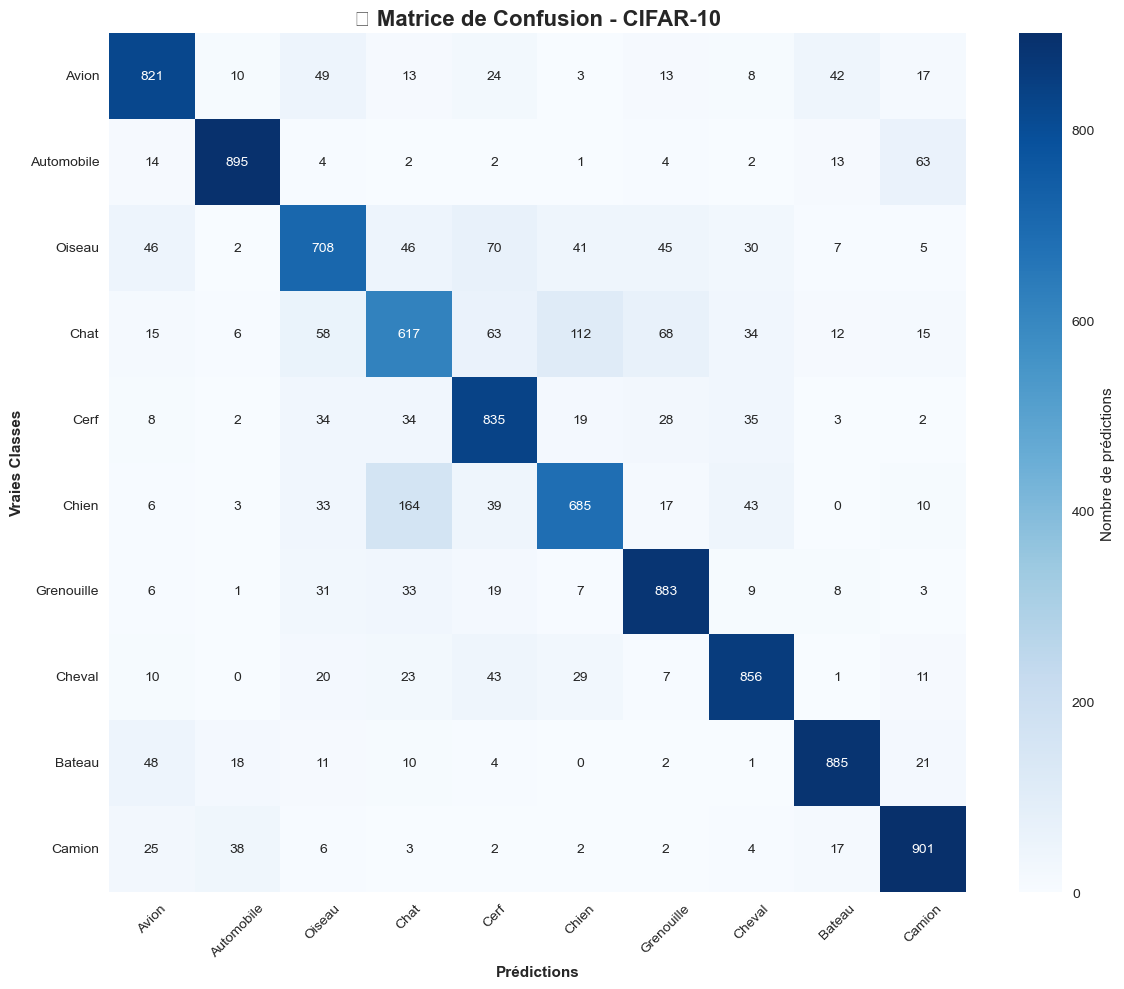


🔍 Analyse des Erreurs les Plus Fréquentes:
❌ 164 fois: Chien → Chat
❌ 112 fois: Chat → Chien
❌  70 fois: Oiseau → Cerf
❌  68 fois: Chat → Grenouille
❌  63 fois: Chat → Cerf


In [13]:
# Matrice de confusion
cm = confusion_matrix(y_test_flat, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title('🔥 Matrice de Confusion - CIFAR-10', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions', fontweight='bold')
plt.ylabel('Vraies Classes', fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analyse des erreurs les plus fréquentes
print("\n🔍 Analyse des Erreurs les Plus Fréquentes:")
print("=" * 50)

# Trouver les erreurs (hors diagonale)
errors = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            errors.append((cm[i, j], class_names[i], class_names[j]))

# Trier par nombre d'erreurs
errors.sort(reverse=True)

for count, true_class, pred_class in errors[:5]:
    print(f"❌ {count:3d} fois: {true_class} → {pred_class}")

## 🖼️ 8. Interface Interactive - Testez Vos Propres Images!

### 📤 Upload et Prédiction en Temps Réel

In [14]:
def preprocess_uploaded_image(image_data):
    """Préprocesse une image uploadée pour la prédiction"""
    try:
        # Décoder l'image base64
        image_bytes = base64.b64decode(image_data.split(',')[1])
        image = Image.open(io.BytesIO(image_bytes))
        
        # Convertir en RGB si nécessaire
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        # Redimensionner à 32x32
        image = image.resize((32, 32))
        
        # Convertir en array numpy et normaliser
        image_array = np.array(image) / 255.0
        
        return image_array
    except Exception as e:
        print(f"❌ Erreur lors du traitement de l'image: {e}")
        return None

def predict_image(image_array):
    """Fait une prédiction sur une image"""
    if image_array is None:
        return None, None
    
    # Ajouter la dimension batch
    image_batch = np.expand_dims(image_array, axis=0)
    
    # Prédiction
    predictions = model.predict(image_batch, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class]
    
    return predicted_class, confidence, predictions[0]

# Widget pour upload d'image
upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='📤 Choisir image'
)

output_widget = widgets.Output()

def on_upload_change(change):
    """Callback quand une image est uploadée"""
    with output_widget:
        clear_output(wait=True)
        
        if upload_widget.value:
            # Récupérer l'image
            uploaded_file = list(upload_widget.value.values())[0]
            image_data = base64.b64encode(uploaded_file['content']).decode()
            image_data = f"data:image/jpeg;base64,{image_data}"
            
            # Préprocesser
            image_array = preprocess_uploaded_image(image_data)
            
            if image_array is not None:
                # Prédiction
                pred_class, confidence, all_probs = predict_image(image_array)
                
                # Affichage des résultats
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
                # Image originale
                axes[0].imshow(image_array)
                axes[0].set_title(f'🖼️ Image Uploadée\n(redimensionnée 32x32)', 
                                fontweight='bold')
                axes[0].axis('off')
                
                # Prédictions
                y_pos = np.arange(len(class_names))
                bars = axes[1].barh(y_pos, all_probs, color=sns.color_palette("husl", 10))
                axes[1].set_yticks(y_pos)
                axes[1].set_yticklabels(class_names)
                axes[1].set_xlabel('Probabilité')
                axes[1].set_title('🎯 Prédictions du Modèle', fontweight='bold')
                
                # Mettre en évidence la prédiction principale
                bars[pred_class].set_color('red')
                bars[pred_class].set_alpha(0.8)
                
                plt.tight_layout()
                plt.show()
                
                # Résultat textuel
                print(f"🎯 Prédiction: {class_names[pred_class]}")
                print(f"🔥 Confiance: {confidence:.1%}")
                
                if confidence > 0.8:
                    print("✅ Prédiction très confiante!")
                elif confidence > 0.5:
                    print("⚠️ Prédiction modérément confiante")
                else:
                    print("❌ Prédiction peu confiante")
            else:
                print("❌ Impossible de traiter l'image")

upload_widget.observe(on_upload_change, names='value')

print("🎮 Interface Interactive - Testez Vos Images!")
print("=" * 50)
print("📝 Instructions:")
print("1. Cliquez sur 'Choisir image' ci-dessous")
print("2. Sélectionnez une image depuis votre ordinateur")
print("3. Le modèle analysera automatiquement votre image!")
print("\n💡 Conseil: Utilisez des images claires des 10 classes CIFAR-10")

display(upload_widget, output_widget)

🎮 Interface Interactive - Testez Vos Images!
📝 Instructions:
1. Cliquez sur 'Choisir image' ci-dessous
2. Sélectionnez une image depuis votre ordinateur
3. Le modèle analysera automatiquement votre image!

💡 Conseil: Utilisez des images claires des 10 classes CIFAR-10


FileUpload(value={}, accept='image/*', description='📤 Choisir image')

Output()

## 📊 9. Analyse des Performances par Classe

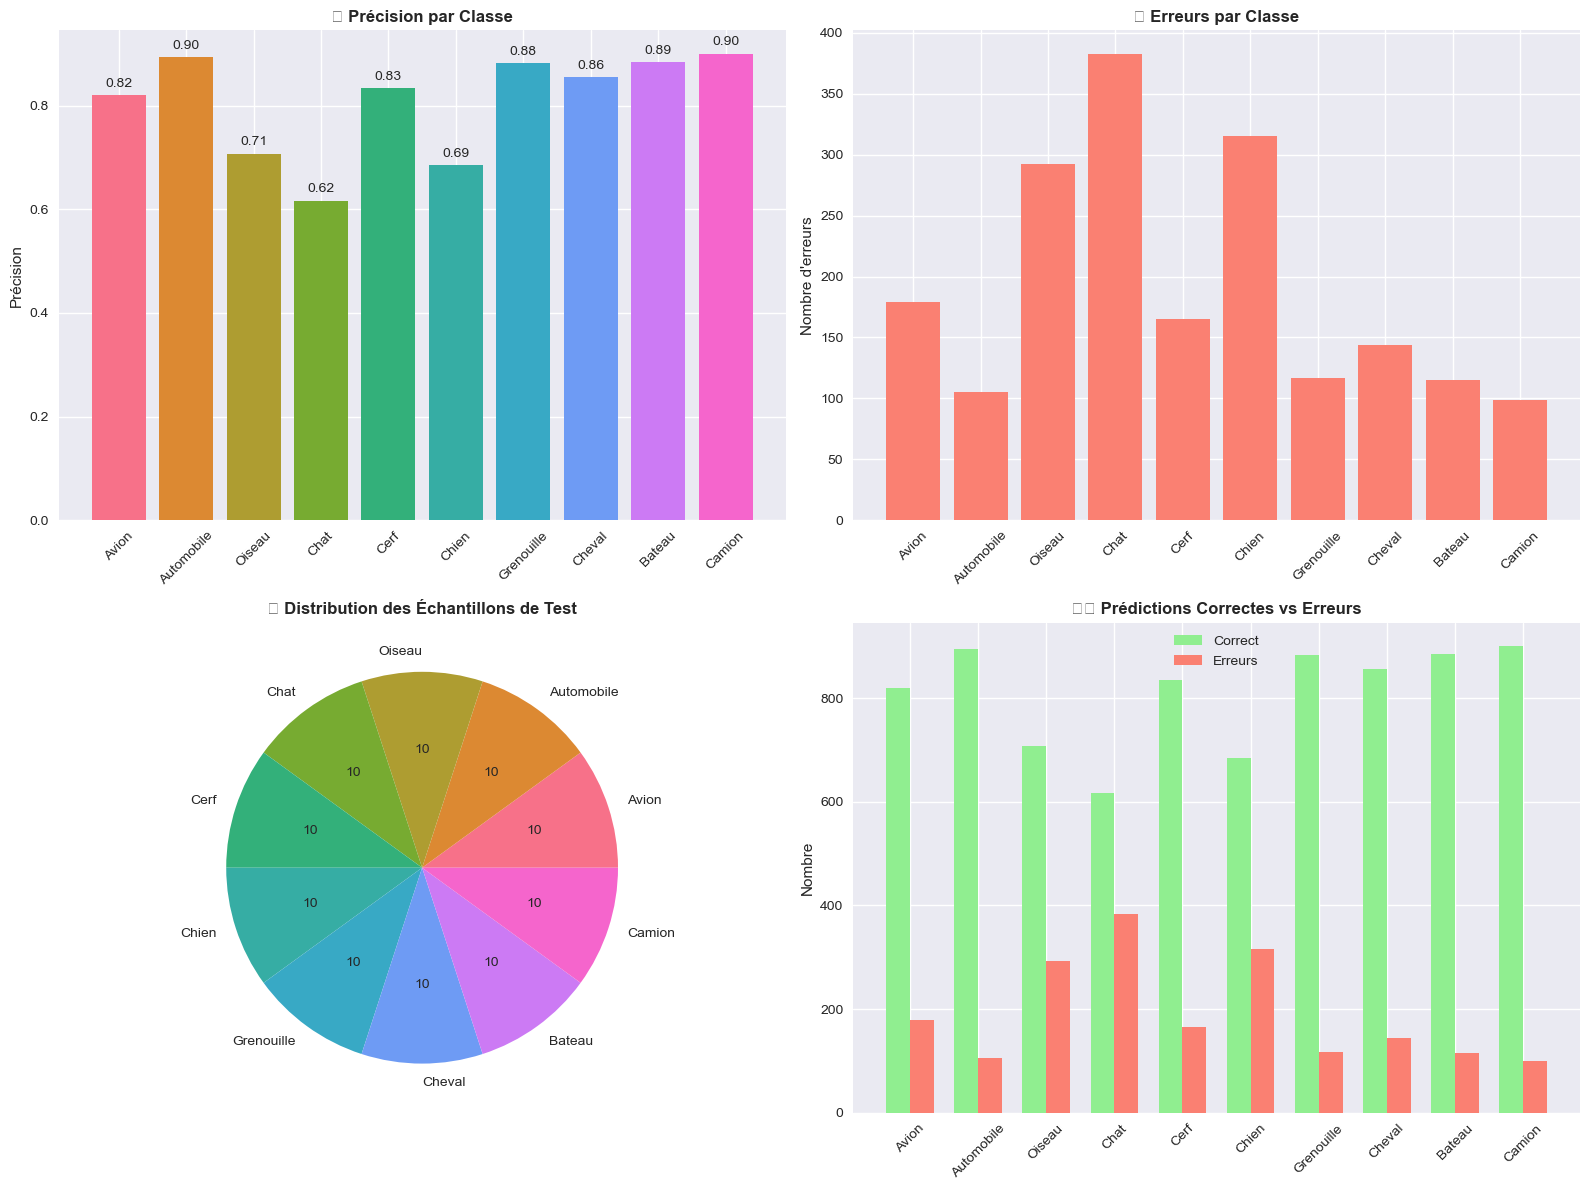

📋 Résumé des Performances par Classe:


,Classe,Précision,Échantillons,Correct,Erreurs
0,Avion,0.821,1000,821,179
1,Automobile,0.895,1000,895,105
2,Oiseau,0.708,1000,708,292
3,Chat,0.617,1000,617,383
4,Cerf,0.835,1000,835,165
5,Chien,0.685,1000,685,315
6,Grenouille,0.883,1000,883,117
7,Cheval,0.856,1000,856,144
8,Bateau,0.885,1000,885,115
9,Camion,0.901,1000,901,99



🏆 Meilleure classe: Camion (90.1%)
🔻 Classe difficile: Chat (61.7%)


In [15]:
# Analyse détaillée par classe
def analyze_class_performance():
    """Analyse les performances par classe"""
    
    # Calcul des métriques par classe
    class_metrics = []
    for i, class_name in enumerate(class_names):
        # Indices de la classe
        class_indices = (y_test_flat == i)
        class_predictions = y_pred_classes[class_indices]
        
        # Métriques
        accuracy = accuracy_score(y_test_flat[class_indices], class_predictions)
        total_samples = np.sum(class_indices)
        correct_predictions = np.sum(class_predictions == i)
        
        class_metrics.append({
            'Classe': class_name,
            'Précision': accuracy,
            'Échantillons': total_samples,
            'Correct': correct_predictions,
            'Erreurs': total_samples - correct_predictions
        })
    
    # DataFrame pour visualisation
    metrics_df = pd.DataFrame(class_metrics)
    
    # Graphique des performances
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Précision par classe
    bars1 = axes[0, 0].bar(metrics_df['Classe'], metrics_df['Précision'], 
                          color=sns.color_palette("husl", 10))
    axes[0, 0].set_title('🎯 Précision par Classe', fontweight='bold')
    axes[0, 0].set_ylabel('Précision')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Ajouter les valeurs sur les barres
    for bar, precision in zip(bars1, metrics_df['Précision']):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{precision:.2f}', ha='center', va='bottom')
    
    # Nombre d'erreurs par classe
    bars2 = axes[0, 1].bar(metrics_df['Classe'], metrics_df['Erreurs'], 
                          color='salmon')
    axes[0, 1].set_title('❌ Erreurs par Classe', fontweight='bold')
    axes[0, 1].set_ylabel('Nombre d\'erreurs')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Distribution des échantillons
    axes[1, 0].pie(metrics_df['Échantillons'], labels=metrics_df['Classe'], 
                   autopct='%1.0f', colors=sns.color_palette("husl", 10))
    axes[1, 0].set_title('📊 Distribution des Échantillons de Test', fontweight='bold')
    
    # Comparaison Correct vs Erreurs
    x_pos = np.arange(len(class_names))
    width = 0.35
    
    bars3 = axes[1, 1].bar(x_pos - width/2, metrics_df['Correct'], width, 
                          label='Correct', color='lightgreen')
    bars4 = axes[1, 1].bar(x_pos + width/2, metrics_df['Erreurs'], width, 
                          label='Erreurs', color='salmon')
    
    axes[1, 1].set_title('✅❌ Prédictions Correctes vs Erreurs', fontweight='bold')
    axes[1, 1].set_ylabel('Nombre')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels(class_names, rotation=45)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Tableau récapitulatif
    print("📋 Résumé des Performances par Classe:")
    print("=" * 60)
    display(metrics_df.round(3))
    
    # Classes les mieux/moins bien classées
    best_class = metrics_df.loc[metrics_df['Précision'].idxmax()]
    worst_class = metrics_df.loc[metrics_df['Précision'].idxmin()]
    
    print(f"\n🏆 Meilleure classe: {best_class['Classe']} ({best_class['Précision']:.1%})")
    print(f"🔻 Classe difficile: {worst_class['Classe']} ({worst_class['Précision']:.1%})")

analyze_class_performance()

## 🎓 10. Résumé et Conclusions

### ✅ Ce que nous avons accompli :

1. **📊 Dataset CIFAR-10** : Chargé et exploré 60,000 images en 10 classes
2. **🏗️ Modèle CNN** : Construit une architecture avec convolutions, pooling, et dropout
3. **🚀 Entraînement** : Optimisé avec callbacks et validation
4. **📈 Évaluation** : Métriques complètes, matrice de confusion, analyse par classe
5. **🎮 Interface Interactive** : Test en temps réel avec vos propres images

### 🎯 Métriques Finales du Modèle :

In [16]:
# Résumé final des performances
print("🎯 RÉSUMÉ FINAL DES PERFORMANCES")
print("=" * 50)
print(f"📊 Précision globale: {test_accuracy:.1%}")
print(f"📉 Perte finale: {test_loss:.3f}")

# Calcul de métriques supplémentaires
from sklearn.metrics import precision_score, recall_score, f1_score

precision_macro = precision_score(y_test_flat, y_pred_classes, average='macro')
recall_macro = recall_score(y_test_flat, y_pred_classes, average='macro')
f1_macro = f1_score(y_test_flat, y_pred_classes, average='macro')

print(f"🎯 Précision moyenne: {precision_macro:.1%}")
print(f"🔍 Rappel moyen: {recall_macro:.1%}")
print(f"⚖️ F1-Score moyen: {f1_macro:.1%}")

# Comparaison avec un classificateur aléatoire
random_accuracy = 1/10  # 10 classes
improvement = (test_accuracy - random_accuracy) / random_accuracy * 100

print(f"\n📈 Amélioration vs aléatoire: +{improvement:.0f}%")

# Conseils pour améliorer
print("\n💡 CONSEILS POUR AMÉLIORER LE MODÈLE:")
print("=" * 40)
print("🔧 Techniques avancées à essayer:")
print("   • Data Augmentation (rotation, zoom, flip)")
print("   • Transfer Learning (ResNet, VGG, etc.)")
print("   • Ensembling (combiner plusieurs modèles)")
print("   • Hyperparameter tuning (learning rate, architecture)")
print("   • Plus d'époques avec early stopping")

print("\n🎉 Félicitations! Vous avez créé votre premier modèle de Computer Vision!")

🎯 RÉSUMÉ FINAL DES PERFORMANCES
📊 Précision globale: 80.9%
📉 Perte finale: 0.561
🎯 Précision moyenne: 80.7%
🔍 Rappel moyen: 80.9%
⚖️ F1-Score moyen: 80.7%

📈 Amélioration vs aléatoire: +709%

💡 CONSEILS POUR AMÉLIORER LE MODÈLE:
🔧 Techniques avancées à essayer:
   • Data Augmentation (rotation, zoom, flip)
   • Transfer Learning (ResNet, VGG, etc.)
   • Ensembling (combiner plusieurs modèles)
   • Hyperparameter tuning (learning rate, architecture)
   • Plus d'époques avec early stopping

🎉 Félicitations! Vous avez créé votre premier modèle de Computer Vision!


## 🚀 Exercices Pratiques

### 🎯 Défis à relever :

1. **📸 Testez différentes images** : Essayez des photos de votre téléphone
2. **🔧 Modifiez l'architecture** : Ajoutez/supprimez des couches
3. **📊 Data Augmentation** : Implémentez des transformations d'images
4. **🏆 Transfer Learning** : Utilisez un modèle pré-entraîné
5. **📈 Optimisation** : Testez différents optimizers et learning rates

### 💡 Questions de Réflexion :

- Pourquoi certaines classes sont-elles mieux classées que d'autres ?
- Comment améliorer les performances sur les classes difficiles ?
- Que se passe-t-il si on teste des images très différentes de CIFAR-10 ?

---
**🎓 Bravo ! Vous maîtrisez maintenant les bases du Computer Vision avec les CNNs !**